In [33]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score,roc_auc_score,  recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier 

In [17]:
df = pd.read_csv("../data/disease10k.csv")

In [20]:
df.head()

,age,bmi,blood_pressure,glucose_level,family_history,physical_activity_level,has_disease
0,24,21.5,108,90,0,low,0
1,70,24.5,124,105,0,moderate,0
2,62,29.0,118,124,0,high,0
3,47,24.0,140,129,0,low,0
4,47,26.0,140,114,1,moderate,0


In [21]:
df = pd.get_dummies(df, columns=["physical_activity_level"], drop_first=True)

X = df.drop("has_disease", axis=1)
y = df["has_disease"]

In [22]:
df.head()


,age,bmi,blood_pressure,glucose_level,family_history,has_disease,physical_activity_level_low,physical_activity_level_moderate
0,24,21.5,108,90,0,0,True,False
1,70,24.5,124,105,0,0,False,True
2,62,29.0,118,124,0,0,False,False
3,47,24.0,140,129,0,0,True,False
4,47,26.0,140,114,1,0,False,True


In [23]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (7000, 7)
Validation shape: (1500, 7)
Test shape: (1500, 7)


In [24]:
rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced"]
}

In [25]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=25,
    scoring="f1",          # good when positive class is rare
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'bootstrap': [True, False], 'class_weight': [None, 'balanced'], 'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,n_iter,25
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
print("Best params:")
print(random_search.best_params_)

print("\nBest CV score:")
print(random_search.best_score_)


Best params:
{'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15, 'class_weight': 'balanced', 'bootstrap': True}

Best CV score:
0.2707557347263229


In [34]:
best_rf = random_search.best_estimator_

y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)[:, 1]

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred, zero_division=0))
print("Validation Recall:", recall_score(y_val, y_val_pred, zero_division=0))
print("Validation F1:", f1_score(y_val, y_val_pred, zero_division=0))
print("Validation ROC-AUC:", roc_auc_score(y_val, y_val_proba))

print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, zero_division=0))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Validation Accuracy: 0.98
Validation Precision: 0.26666666666666666
Validation Recall: 0.17391304347826086
Validation F1: 0.21052631578947367
Validation ROC-AUC: 0.8861528951164228

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1477
           1       0.27      0.17      0.21        23

    accuracy                           0.98      1500
   macro avg       0.63      0.58      0.60      1500
weighted avg       0.98      0.98      0.98      1500


Validation Confusion Matrix:
[[1466   11]
 [  19    4]]


In [35]:
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

final_rf = RandomForestClassifier(
    **random_search.best_params_,
    random_state=42
)

final_rf.fit(X_train_full, y_train_full)

,n_estimators,300
,criterion,'gini'
,max_depth,15
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
y_test_pred = final_rf.predict(X_test)
y_test_proba = final_rf.predict_proba(X_test)[:, 1]

print("TEST Accuracy:", accuracy_score(y_test, y_test_pred))
print("TEST Precision:", precision_score(y_test, y_test_pred, zero_division=0))
print("TEST Recall:", recall_score(y_test, y_test_pred, zero_division=0))
print("TEST F1:", f1_score(y_test, y_test_pred, zero_division=0))
print("TEST ROC-AUC:", roc_auc_score(y_test, y_test_proba))

print("\nTEST Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("\nTEST Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

TEST Accuracy: 0.9773333333333334
TEST Precision: 0.125
TEST Recall: 0.09090909090909091
TEST F1: 0.10526315789473684
TEST ROC-AUC: 0.8880858654201009

TEST Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1478
           1       0.12      0.09      0.11        22

    accuracy                           0.98      1500
   macro avg       0.56      0.54      0.55      1500
weighted avg       0.97      0.98      0.98      1500


TEST Confusion Matrix:
[[1464   14]
 [  20    2]]


In [38]:
feature_importance = pd.DataFrame({
    "feature": X_train_full.columns,
    "importance": final_rf.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance)

                            feature  importance
3                     glucose_level    0.276070
0                               age    0.248144
1                               bmi    0.186613
2                    blood_pressure    0.169874
4                    family_history    0.080825
5       physical_activity_level_low    0.023553
6  physical_activity_level_moderate    0.014922


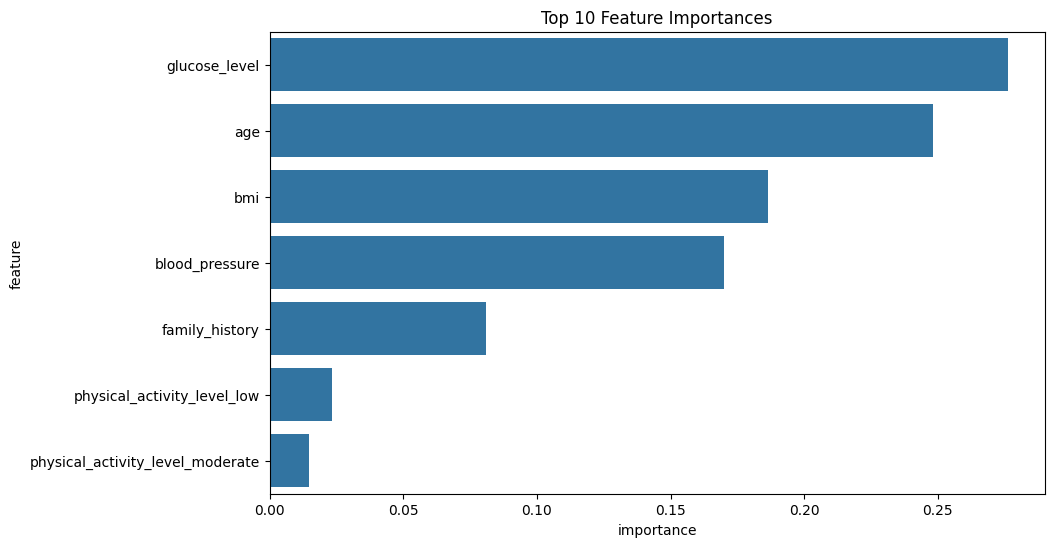

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=feature_importance.head(10))
plt.title("Top 10 Feature Importances")
plt.show()